# 📈 Clase 2 — Regresión lineal simple
## Unidad: Correlación y modelamiento

**Situación:** El equipo de marketing quiere estimar cuánto gastará un cliente en función del tiempo que pasa navegando en la tienda online. Necesitas construir un modelo que permita hacer esa predicción.

**Preguntas clave:**
- ¿Se puede predecir el gasto a partir del tiempo de navegación?
- ¿Cómo sabemos si el modelo es bueno?

**Objetivos:**
- Entender la estructura del modelo Y = β₀ + β₁X + ε
- Calcular coeficientes con **OLS** (`statsmodels`)
- Interpretar intercepto (β₀) y pendiente (β₁)
- Evaluar con métricas de error: **MAE**, **MSE**, **RMSE**
- Medir ajuste con **R²**

In [3]:
%pip install statsmodels scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.5 MB 2.4 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.5 MB 2.9 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.5 MB 3.1 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.5 MB 3.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 3.5 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.5 MB 3.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 3.7 MB/s  0:00:02
   ---------------------------------------

In [4]:
!pip install statsmodels

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.6 MB/s eta 0:00:00
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
    --------------------------------------- 0.2/9.6 MB 5.3 MB/s eta 0:00:02
   - -------------------------------------- 0.4/9.6 MB 3.3 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/9.6 MB 3.2 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.6 MB 3.4 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.6 MB 3.4 MB/s eta 0:00:03
   ---- ----------------------------------- 1.2/9.6 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.4/9.6 MB 3.3 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.6 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.0/9.6 MB 3.6 MB/s eta 0:00:03
   -------- -----------------


[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: C:\Python311\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')
print(f'statsmodels {sm.__version__} | pandas {pd.__version__}')

✅ Librerías cargadas
statsmodels 0.14.6 | pandas 3.0.3


---
## PARTE 1 — Estructura del modelo de regresión lineal simple

### 1.1 Ejemplo introductorio de la presentación

In [6]:
# Datos exactos de la presentación
df_intro = pd.DataFrame({
    'tiempo': [1, 2, 3, 4, 5, 6, 7],
    'gasto':  [20, 23, 25, 30, 32, 34, 38]
})

X_i = sm.add_constant(df_intro['tiempo'])
Y_i = df_intro['gasto']
modelo_intro = sm.OLS(Y_i, X_i).fit()

print(modelo_intro.summary())

                            OLS Regression Results                            
Dep. Variable:                  gasto   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     436.0
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           4.67e-06
Time:                        18:55:21   Log-Likelihood:                -6.7522
No. Observations:                   7   AIC:                             17.50
Df Residuals:                       5   BIC:                             17.40
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.0000      0.635     26.777      0.0

c:\Users\Natalie\anaconda3\envs\BootcampCienciaDeDatos\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [7]:
b0 = modelo_intro.params['const']
b1 = modelo_intro.params['tiempo']

print(f'β₀ (Intercepto): {b0:.2f}')
print(f'β₁ (Pendiente):  {b1:.2f}')
print()
print('Interpretación:')
print(f'  Si una persona no navega (X=0), se espera un gasto base de ${b0:.2f}')
print(f'  Por cada minuto adicional de navegación, el gasto aumenta en ${b1:.2f}')
print()
print(f'Ecuación del modelo: ŷ = {b0:.2f} + {b1:.2f} × tiempo')
print()
# Predicción ejemplo
tiempo_nuevo = 5
pred_nueva = b0 + b1 * tiempo_nuevo
print(f'Predicción para tiempo = {tiempo_nuevo} min: ŷ = ${pred_nueva:.2f}')

β₀ (Intercepto): 17.00
β₁ (Pendiente):  2.96

Interpretación:
  Si una persona no navega (X=0), se espera un gasto base de $17.00
  Por cada minuto adicional de navegación, el gasto aumenta en $2.96

Ecuación del modelo: ŷ = 17.00 + 2.96 × tiempo

Predicción para tiempo = 5 min: ŷ = $31.82


### 1.2 Cálculo manual de β₁ y β₀ (fórmulas OLS)

In [8]:
X_vals = df_intro['tiempo'].values
Y_vals = df_intro['gasto'].values
X_mean, Y_mean = X_vals.mean(), Y_vals.mean()

numerador   = np.sum((X_vals - X_mean) * (Y_vals - Y_mean))
denominador = np.sum((X_vals - X_mean) ** 2)

b1_manual = numerador / denominador
b0_manual = Y_mean - b1_manual * X_mean

print('=== Cálculo manual de coeficientes OLS ===')
print(f'X̄ = {X_mean:.2f} | Ȳ = {Y_mean:.2f}')
print(f'Σ(Xi-X̄)(Yi-Ȳ) = {numerador:.2f}')
print(f'Σ(Xi-X̄)²      = {denominador:.2f}')
print(f'β₁ = {numerador:.2f} / {denominador:.2f} = {b1_manual:.4f}')
print(f'β₀ = Ȳ - β₁·X̄ = {Y_mean:.2f} - {b1_manual:.4f}·{X_mean:.2f} = {b0_manual:.4f}')
print()
print(f'Verificación con statsmodels → β₀={b0:.4f} | β₁={b1:.4f} ✅')

=== Cálculo manual de coeficientes OLS ===
X̄ = 4.00 | Ȳ = 28.86
Σ(Xi-X̄)(Yi-Ȳ) = 83.00
Σ(Xi-X̄)²      = 28.00
β₁ = 83.00 / 28.00 = 2.9643
β₀ = Ȳ - β₁·X̄ = 28.86 - 2.9643·4.00 = 17.0000

Verificación con statsmodels → β₀=17.0000 | β₁=2.9643 ✅


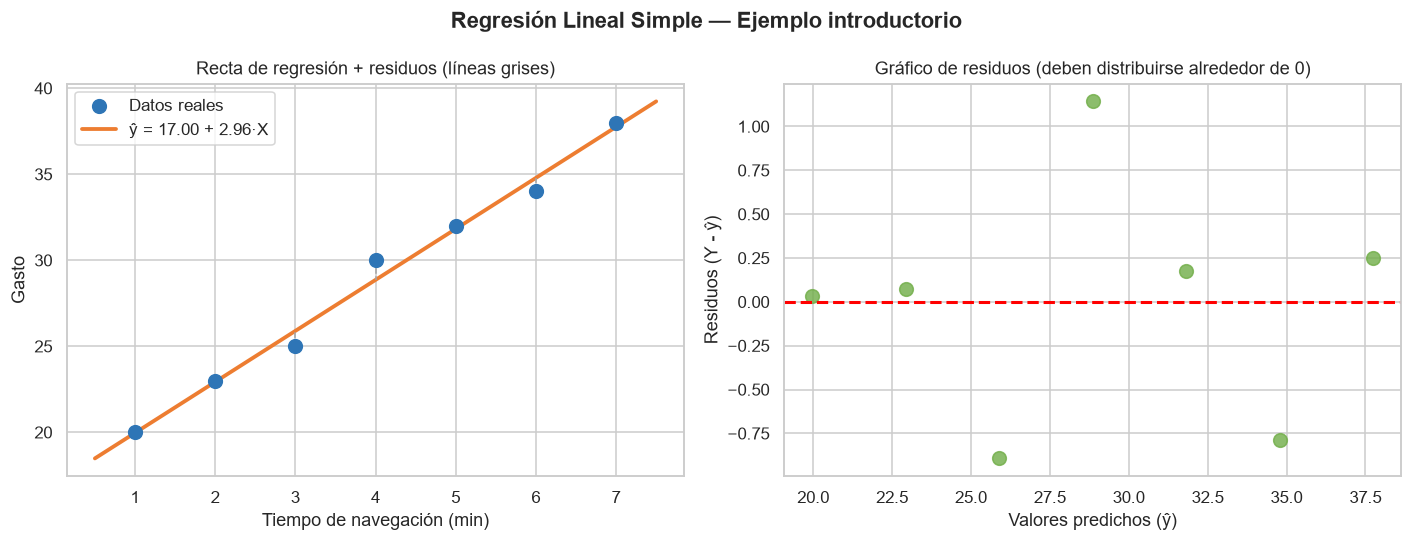

In [9]:
# Visualización del modelo con residuos
pred_i = modelo_intro.predict(X_i)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regresión Lineal Simple — Ejemplo introductorio', fontweight='bold')

# Scatterplot + recta de regresión
axes[0].scatter(df_intro['tiempo'], df_intro['gasto'],
                color='#2E75B6', s=80, zorder=5, label='Datos reales')
x_line = np.linspace(0.5, 7.5, 100)
axes[0].plot(x_line, b0 + b1 * x_line, color='#ED7D31', linewidth=2.5,
             label=f'ŷ = {b0:.2f} + {b1:.2f}·X')
# Residuos
for xi, yi, pi in zip(df_intro['tiempo'], df_intro['gasto'], pred_i):
    axes[0].plot([xi, xi], [yi, pi], color='#A5A5A5', linestyle='--', linewidth=1)
axes[0].set_title('Recta de regresión + residuos (líneas grises)')
axes[0].set_xlabel('Tiempo de navegación (min)')
axes[0].set_ylabel('Gasto')
axes[0].legend()

# Residuos vs valores predichos
residuos = Y_i - pred_i
axes[1].scatter(pred_i, residuos, color='#70AD47', s=80, alpha=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Gráfico de residuos (deben distribuirse alrededor de 0)')
axes[1].set_xlabel('Valores predichos (ŷ)')
axes[1].set_ylabel('Residuos (Y - ŷ)')

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 1 — Reflexiona:

In [10]:
# ✏️ ¿Qué significa un residuo positivo? ¿Y uno negativo?
r_residuo = ""

# ✏️ ¿Qué esperaríamos ver en el gráfico de residuos si el modelo es bueno?
r_buen_modelo = ""

# ✏️ ¿Cuánto gastaría una persona que navega 10 minutos? Calcula con la ecuación:
pred_10 = b0 + b1 * 10
print(f'Predicción para 10 min: ŷ = {b0:.2f} + {b1:.2f}×10 = {pred_10:.2f}')

# ✏️ ¿Tiene sentido interpretar β₀ en este contexto (tiempo=0)?
r_intercepto = ""

print(f'\nResiduos: {r_residuo}')
print(f'Buen modelo: {r_buen_modelo}')
print(f'β₀ con X=0: {r_intercepto}')

Predicción para 10 min: ŷ = 17.00 + 2.96×10 = 46.64

Residuos: 
Buen modelo: 
β₀ con X=0: 


---
## PARTE 2 — Métricas de error y R²

### 2.1 MAE, MSE, RMSE — calculados paso a paso

In [11]:
# Código exacto de la presentación
predicciones = modelo_intro.predict(X_i)
mae  = np.mean(np.abs(Y_i - predicciones))
mse  = np.mean((Y_i - predicciones) ** 2)
rmse = np.sqrt(mse)

print('=== Métricas de error — Ejemplo introductorio ===')
print(f'MAE:   {mae:.4f}  → error medio absoluto en las mismas unidades de Y')
print(f'MSE:   {mse:.4f}  → penaliza errores grandes (en unidades²)')
print(f'RMSE:  {rmse:.4f} → interpretable en las mismas unidades de Y')
print()
# Contexto: comparar RMSE con desv.std de Y
std_y = Y_i.std()
print(f'Desviación estándar de Y: {std_y:.4f}')
print(f'RMSE / std(Y):             {rmse/std_y:.3f}  → si < 0.5, el modelo es razonable')

=== Métricas de error — Ejemplo introductorio ===
MAE:   0.4796  → error medio absoluto en las mismas unidades de Y
MSE:   0.4031  → penaliza errores grandes (en unidades²)
RMSE:  0.6349 → interpretable en las mismas unidades de Y

Desviación estándar de Y: 6.4402
RMSE / std(Y):             0.099  → si < 0.5, el modelo es razonable


In [12]:
# Mostrar el cálculo de cada error individualmente
tabla_errores = pd.DataFrame({
    'X (tiempo)': df_intro['tiempo'].values,
    'Y real':     Y_i.values,
    'ŷ pred':     predicciones.round(2).values,
    'Residuo (Y-ŷ)': (Y_i - predicciones).round(2).values,
    '|Residuo|':  np.abs(Y_i - predicciones).round(2).values,
    'Residuo²':   ((Y_i - predicciones)**2).round(2).values
})

print('=== Tabla de residuos ===')
print(tabla_errores.to_string(index=False))
print()
print(f'Suma |Residuo| / n = {tabla_errores["|Residuo|"].sum():.4f} / {len(Y_i)} = MAE = {mae:.4f}')
print(f'Suma Residuo² / n  = {tabla_errores["Residuo²"].sum():.4f} / {len(Y_i)} = MSE = {mse:.4f}')

=== Tabla de residuos ===
 X (tiempo)  Y real  ŷ pred  Residuo (Y-ŷ)  |Residuo|  Residuo²
          1      20   19.96           0.04       0.04      0.00
          2      23   22.93           0.07       0.07      0.01
          3      25   25.89          -0.89       0.89      0.80
          4      30   28.86           1.14       1.14      1.31
          5      32   31.82           0.18       0.18      0.03
          6      34   34.79          -0.79       0.79      0.62
          7      38   37.75           0.25       0.25      0.06

Suma |Residuo| / n = 3.3600 / 7 = MAE = 0.4796
Suma Residuo² / n  = 2.8300 / 7 = MSE = 0.4031


### 2.2 Coeficiente de determinación R²

In [13]:
# Código exacto de la presentación
r2 = modelo_intro.rsquared
print(f'R² = {r2:.4f}')
print(f'Interpretación: el modelo explica el {r2*100:.1f}% de la variabilidad de Y')
print()

# Cálculo manual de R²
SSE = np.sum((Y_i - predicciones) ** 2)          # suma cuadrados del error
SST = np.sum((Y_i - Y_i.mean()) ** 2)            # suma total de cuadrados
r2_manual = 1 - (SSE / SST)

print(f'Cálculo manual: R² = 1 - SSE/SST = 1 - {SSE:.4f}/{SST:.4f} = {r2_manual:.4f}')
print()

# Escala de interpretación
tabla_r2 = pd.DataFrame({
    'Rango R²': ['≥ 0.90', '0.70–0.89', '0.50–0.69', '< 0.50'],
    'Interpretación': ['Ajuste excelente','Ajuste bueno','Ajuste moderado','Ajuste débil']
})
print(tabla_r2.to_string(index=False))

R² = 0.9887
Interpretación: el modelo explica el 98.9% de la variabilidad de Y

Cálculo manual: R² = 1 - SSE/SST = 1 - 2.8214/248.8571 = 0.9887

 Rango R²   Interpretación
   ≥ 0.90 Ajuste excelente
0.70–0.89     Ajuste bueno
0.50–0.69  Ajuste moderado
   < 0.50     Ajuste débil


### ✏️ Ejercicio 2 — Completa:

In [14]:
# ✏️ ¿Cuál es la diferencia entre MAE y RMSE? ¿Cuándo preferirías cada uno?
r_mae_vs_rmse = ""

# ✏️ ¿Qué significa un R² = 0.95? ¿Y un R² = 0.15?
r_r2_alto = ""
r_r2_bajo = ""

# ✏️ Un R² alto, ¿implica que X causa Y? ¿Por qué?
r_causalidad = ""

print(f'MAE vs RMSE: {r_mae_vs_rmse}')
print(f'R²=0.95:     {r_r2_alto}')
print(f'R²=0.15:     {r_r2_bajo}')
print(f'R² y causa:  {r_causalidad}')

MAE vs RMSE: 
R²=0.95:     
R²=0.15:     
R² y causa:  


---
## PARTE 3 — Actividad guiada: Predicción del gasto

### 3.1 Cargar y explorar `navegacion_clientes.csv`

In [15]:
# Código exacto de la presentación
df = pd.read_csv('navegacion_clientes.csv')
print(df.head())
print()
print(df.describe().round(2))

  id_cliente  tiempo_navegacion    gasto
0     CLI001               24.2  18481.0
1     CLI002               24.9  19996.0
2     CLI003                4.3   8419.0
3     CLI004               18.7  16643.0
4     CLI005                5.2   9376.0

       tiempo_navegacion     gasto
count              80.00     79.00
mean               14.70  14815.90
std                 9.19   4036.83
min                -2.00   6799.00
25%                 5.18  11097.00
50%                15.45  15456.00
75%                23.30  17853.00
max                29.70  21642.00


In [16]:
print('=== Info y tipos de dato ===')
print(df.info())
print()
print('=== Valores faltantes ===')
print(df.isnull().sum())
print()
print('=== Valores fuera de rango ===')
print(df[df['tiempo_navegacion'] < 0])

=== Info y tipos de dato ===
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         80 non-null     str    
 1   tiempo_navegacion  80 non-null     float64
 2   gasto              79 non-null     float64
dtypes: float64(2), str(1)
memory usage: 2.0 KB
None

=== Valores faltantes ===
id_cliente           0
tiempo_navegacion    0
gasto                1
dtype: int64

=== Valores fuera de rango ===
   id_cliente  tiempo_navegacion    gasto
12     CLI013               -2.0  11670.0


In [17]:
# Limpieza de los errores intencionales
df_clean = df.dropna(subset=['gasto']).copy()
df_clean = df_clean[df_clean['tiempo_navegacion'] > 0]
df_clean['gasto'] = pd.to_numeric(df_clean['gasto'], errors='coerce')
df_clean = df_clean.dropna()

print(f'Registros originales: {len(df)} | Después de limpieza: {len(df_clean)}')

Registros originales: 80 | Después de limpieza: 78


### 3.2 Exploración visual (antes de ajustar)

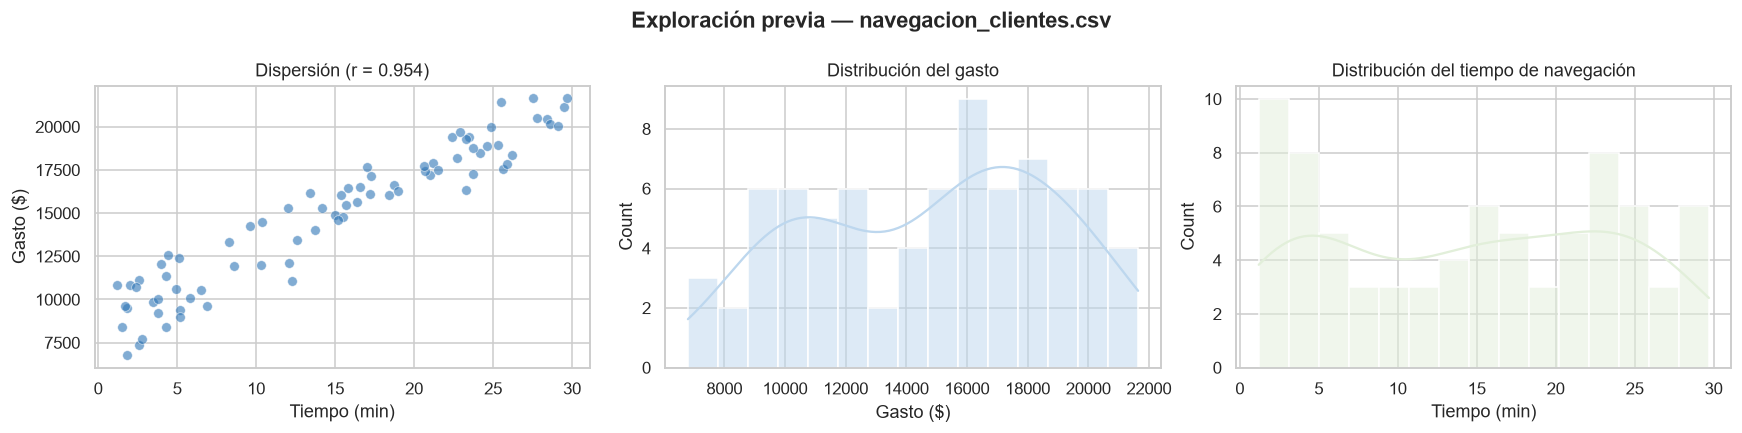

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploración previa — navegacion_clientes.csv', fontweight='bold')

# Scatterplot
sns.scatterplot(data=df_clean, x='tiempo_navegacion', y='gasto',
                ax=axes[0], color='#2E75B6', alpha=0.6, s=40)
axes[0].set_title('Dispersión: tiempo vs gasto')
axes[0].set_xlabel('Tiempo (min)')
axes[0].set_ylabel('Gasto ($)')

# Histograma de gasto
sns.histplot(df_clean['gasto'], bins=15, kde=True, ax=axes[1], color='#BDD7EE')
axes[1].set_title('Distribución del gasto')
axes[1].set_xlabel('Gasto ($)')

# Histograma de tiempo
sns.histplot(df_clean['tiempo_navegacion'], bins=15, kde=True, ax=axes[2], color='#E2EFDA')
axes[2].set_title('Distribución del tiempo de navegación')
axes[2].set_xlabel('Tiempo (min)')

r_prev = df_clean['tiempo_navegacion'].corr(df_clean['gasto'])
axes[0].set_title(f'Dispersión (r = {r_prev:.3f})')

plt.tight_layout()
plt.show()

### 3.3 Ajustar el modelo de regresión lineal

In [19]:
# Código exacto de la presentación
X = sm.add_constant(df_clean['tiempo_navegacion'])
Y = df_clean['gasto']
modelo = sm.OLS(Y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  gasto   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     767.4
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.83e-41
Time:                        19:01:16   Log-Likelihood:                -664.16
No. Observations:                  78   AIC:                             1332.
Df Residuals:                      76   BIC:                             1337.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              8537.1770    266.84

In [20]:
# Extraer e interpretar coeficientes
b0_g = modelo.params['const']
b1_g = modelo.params['tiempo_navegacion']
pval = modelo.pvalues['tiempo_navegacion']

print('=== Coeficientes del modelo ===')
print(f'β₀ (Intercepto): ${b0_g:,.0f}')
print(f'β₁ (Pendiente):  ${b1_g:,.0f} por minuto de navegación')
print(f'p-value β₁:      {pval:.6f} → {"estadísticamente significativo ✅" if pval < 0.05 else "NO significativo ⚠️"}')
print()
print(f'Ecuación: ŷ = ${b0_g:,.0f} + ${b1_g:,.0f} × tiempo_navegacion')
print()
print('Interpretación contextual:')
print(f'  Gasto base estimado (sin navegación): ${b0_g:,.0f}')
print(f'  Por cada minuto adicional de navegación, el gasto aumenta en ${b1_g:,.0f}')

=== Coeficientes del modelo ===
β₀ (Intercepto): $8,537
β₁ (Pendiente):  $428 por minuto de navegación
p-value β₁:      0.000000 → estadísticamente significativo ✅

Ecuación: ŷ = $8,537 + $428 × tiempo_navegacion

Interpretación contextual:
  Gasto base estimado (sin navegación): $8,537
  Por cada minuto adicional de navegación, el gasto aumenta en $428


### 3.4 Calcular métricas de error y R²

In [21]:
# Código exacto de la presentación
pred = modelo.predict(X)
mae  = np.mean(np.abs(Y - pred))
mse  = np.mean((Y - pred) ** 2)
rmse = np.sqrt(mse)
r2   = modelo.rsquared

print('=== Métricas del modelo — Actividad guiada ===')
print(f'MAE:   ${mae:,.0f}  → error promedio absoluto en predicciones')
print(f'MSE:   ${mse:,.0f}  → penaliza errores grandes')
print(f'RMSE:  ${rmse:,.0f}  → error en las mismas unidades que el gasto')
print(f'R²:    {r2:.4f}  → el modelo explica el {r2*100:.1f}% de la variabilidad del gasto')
print()
print(f'RMSE / std(Y): {rmse/Y.std():.3f}')

=== Métricas del modelo — Actividad guiada ===
MAE:   $969  → error promedio absoluto en predicciones
MSE:   $1,456,952  → penaliza errores grandes
RMSE:  $1,207  → error en las mismas unidades que el gasto
R²:    0.9099  → el modelo explica el 91.0% de la variabilidad del gasto

RMSE / std(Y): 0.298


### 3.5 Visualización del modelo ajustado

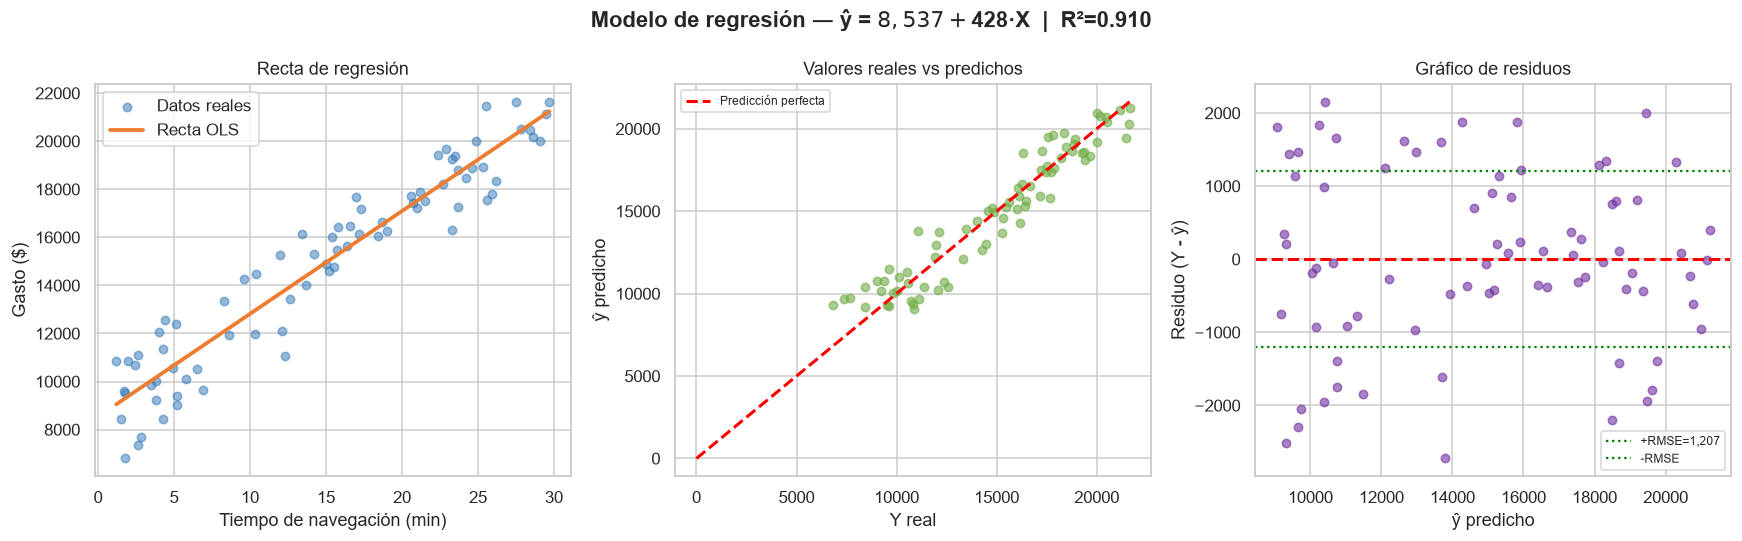

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Modelo de regresión — ŷ = ${b0_g:,.0f} + ${b1_g:,.0f}·X  |  R²={r2:.3f}',
             fontweight='bold')

# 1. Recta de regresión
axes[0].scatter(df_clean['tiempo_navegacion'], Y, color='#2E75B6',
                alpha=0.5, s=30, label='Datos reales')
x_range = np.linspace(df_clean['tiempo_navegacion'].min(),
                      df_clean['tiempo_navegacion'].max(), 100)
axes[0].plot(x_range, b0_g + b1_g * x_range, color='#ED7D31',
             linewidth=2.5, label='Recta OLS')
axes[0].set_title('Recta de regresión')
axes[0].set_xlabel('Tiempo de navegación (min)')
axes[0].set_ylabel('Gasto ($)')
axes[0].legend()

# 2. Valores reales vs predichos
axes[1].scatter(Y, pred, color='#70AD47', alpha=0.6, s=30)
lim = max(Y.max(), pred.max())
axes[1].plot([0, lim], [0, lim], color='red', linestyle='--', linewidth=2,
             label='Predicción perfecta')
axes[1].set_title('Valores reales vs predichos')
axes[1].set_xlabel('Y real')
axes[1].set_ylabel('ŷ predicho')
axes[1].legend(fontsize=8)

# 3. Residuos vs predichos
residuos = Y - pred
axes[2].scatter(pred, residuos, color='#7030A0', alpha=0.6, s=30)
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].axhline(rmse,  color='green', linestyle=':', linewidth=1.5, label=f'+RMSE={rmse:,.0f}')
axes[2].axhline(-rmse, color='green', linestyle=':', linewidth=1.5, label=f'-RMSE')
axes[2].set_title('Gráfico de residuos')
axes[2].set_xlabel('ŷ predicho')
axes[2].set_ylabel('Residuo (Y - ŷ)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### ✏️ Preguntas de reflexión actividad guiada:

In [23]:
# ✏️ ¿Es el RMSE alto o bajo en relación al rango de gastos?
print(f'Rango de gasto: ${Y.min():,.0f} — ${Y.max():,.0f}')
print(f'RMSE:            ${rmse:,.0f}')
r_rmse_contexto = ""

# ✏️ ¿El modelo explica bien la variabilidad del gasto? ¿Qué dice el R²?
r_r2_interp = ""

# ✏️ ¿Qué pasaría si intentáramos predecir el gasto de alguien que navega 60 minutos?
pred_60 = b0_g + b1_g * 60
print(f'Predicción para 60 min: ${pred_60:,.0f}')
r_extrapolacion = ""

print(f'\nRMSE en contexto:  {r_rmse_contexto}')
print(f'R² interpretación: {r_r2_interp}')
print(f'Extrapolación 60min: {r_extrapolacion}')

Rango de gasto: $6,799 — $21,642
RMSE:            $1,207
Predicción para 60 min: $34,206

RMSE en contexto:  
R² interpretación: 
Extrapolación 60min: 


---
## PARTE 4 — Actividad autónoma: modelo individual con nueva muestra

### 4.1 Cargar y explorar `regresion_autonomo.csv`

In [24]:
# Código exacto de la presentación
df2 = pd.read_csv('regresion_autonomo.csv')
print(df2.describe().round(2))

       tiempo_navegacion     gasto
count              60.00     60.00
mean               14.62  14811.65
std                 9.15   3939.36
min                 1.20   5487.00
25%                 6.65  12051.25
50%                13.90  15034.00
75%                23.10  17421.75
max                29.80  23171.00


In [25]:
print(df2.head(8))
print()
print('=== Columnas adicionales ===')
print(df2.dtypes)

  id_cliente  tiempo_navegacion  gasto dispositivo    segmento
0     CLI001                2.5  12371       móvil       nuevo
1     CLI002               12.0  15232      tablet  recurrente
2     CLI003               10.9  14765      tablet  recurrente
3     CLI004               21.3  17974       móvil       nuevo
4     CLI005               27.3  20541     desktop       nuevo
5     CLI006                1.2   5487      tablet  recurrente
6     CLI007                4.0  14160       móvil       nuevo
7     CLI008                9.5  13998     desktop         vip

=== Columnas adicionales ===
id_cliente               str
tiempo_navegacion    float64
gasto                  int64
dispositivo              str
segmento                 str
dtype: object


### 4.2 Ajustar el modelo

In [26]:
# Código exacto de la presentación
X2 = sm.add_constant(df2['tiempo_navegacion'])
Y2 = df2['gasto']
modelo2 = sm.OLS(Y2, X2).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  gasto   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     194.1
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           3.70e-20
Time:                        19:03:38   Log-Likelihood:                -537.28
No. Observations:                  60   AIC:                             1079.
Df Residuals:                      58   BIC:                             1083.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              9287.2845    466.68

### 4.3 Calcular métricas y comparar con el modelo guiado

In [27]:
# Código exacto de la presentación
pred2 = modelo2.predict(X2)
mae2  = np.mean(np.abs(Y2 - pred2))
rmse2 = np.sqrt(np.mean((Y2 - pred2) ** 2))
r2_2  = modelo2.rsquared

print('=== Métricas del modelo autónomo ===')
print(f'MAE:  ${mae2:,.0f}')
print(f'RMSE: ${rmse2:,.0f}')
print(f'R²:   {r2_2:.4f}')

# Comparación directa
print()
print('=== Comparación: Modelo guiado vs Autónomo ===')
comp = pd.DataFrame({
    'Modelo guiado':   [b0_g, b1_g, mae,  rmse,  r2],
    'Modelo autónomo': [modelo2.params['const'],
                        modelo2.params['tiempo_navegacion'],
                        mae2, rmse2, r2_2]
}, index=['β₀ (intercepto)', 'β₁ (pendiente)', 'MAE', 'RMSE', 'R²'])
print(comp.round(2))

=== Métricas del modelo autónomo ===
MAE:  $1,481
RMSE: $1,874
R²:   0.7699

=== Comparación: Modelo guiado vs Autónomo ===
                 Modelo guiado  Modelo autónomo
β₀ (intercepto)        8537.18          9287.28
β₁ (pendiente)          427.82           377.73
MAE                     969.19          1481.08
RMSE                   1207.04          1873.83
R²                        0.91             0.77


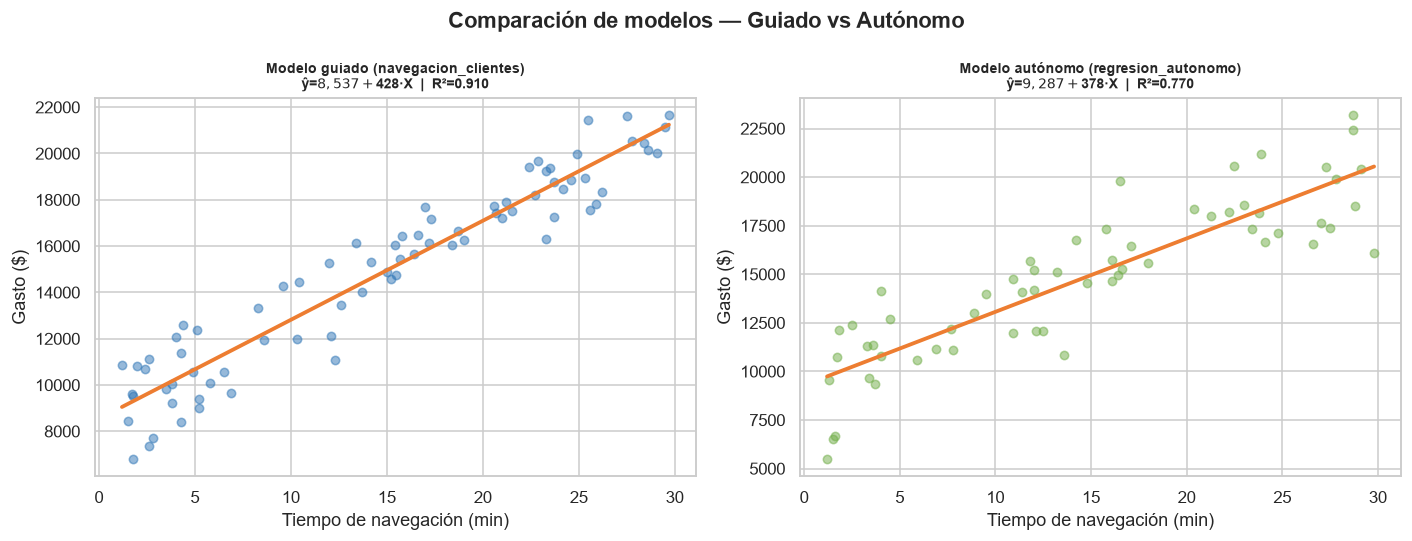

In [28]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparación de modelos — Guiado vs Autónomo', fontweight='bold')

b0_2 = modelo2.params['const']
b1_2 = modelo2.params['tiempo_navegacion']

for ax, df_p, Y_p, b0_p, b1_p, r2_p, titulo, color in zip(
    axes,
    [df_clean, df2],
    [Y, Y2],
    [b0_g, b0_2],
    [b1_g, b1_2],
    [r2, r2_2],
    ['Modelo guiado (navegacion_clientes)', 'Modelo autónomo (regresion_autonomo)'],
    ['#2E75B6', '#70AD47']
):
    ax.scatter(df_p['tiempo_navegacion'], Y_p, color=color, alpha=0.5, s=30)
    x_r = np.linspace(df_p['tiempo_navegacion'].min(),
                      df_p['tiempo_navegacion'].max(), 100)
    ax.plot(x_r, b0_p + b1_p * x_r, color='#ED7D31', linewidth=2.5)
    ax.set_title(f'{titulo}\nŷ=${b0_p:,.0f}+${b1_p:,.0f}·X  |  R²={r2_p:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Tiempo de navegación (min)')
    ax.set_ylabel('Gasto ($)')

plt.tight_layout()
plt.show()

### ✏️ Preguntas de reflexión actividad autónoma:

In [29]:
# ✏️ 1. ¿Qué tan preciso es el modelo con esta nueva muestra?
c1 = ""

# ✏️ 2. ¿Qué diferencias observas respecto a los coeficientes del modelo anterior?
c2 = ""

# ✏️ 3. ¿Cuál de las métricas te parece más útil para comunicar el desempeño a gerencia?
c3 = ""

# ✏️ 4. ¿La relación tiempo→gasto se mantiene estable en ambas muestras?
c4 = ""

# ✏️ 5. ¿Qué variable adicional del dataset autónomo podrías incluir para mejorar el modelo?
c5 = ""

print('--- CONCLUSIONES ACTIVIDAD AUTÓNOMA ---')
for i, c in enumerate([c1, c2, c3, c4, c5], 1):
    print(f'{i}. {c}')

--- CONCLUSIONES ACTIVIDAD AUTÓNOMA ---
1. 
2. 
3. 
4. 
5. 


---
## 📋 Resumen de funciones y buenas prácticas

| Paso | Función | Descripción |
|------|---------|-------------|
| Preparar X | `sm.add_constant(df['X'])` | Agrega columna de intercepto |
| Ajustar modelo | `sm.OLS(Y, X).fit()` | Mínimos cuadrados ordinarios |
| Ver resultados | `modelo.summary()` | Resumen completo del modelo |
| Coeficientes | `modelo.params` | β₀ y β₁ |
| P-values | `modelo.pvalues` | Significancia estadística |
| Predicciones | `modelo.predict(X)` | Valores ŷ |
| R² | `modelo.rsquared` | Capacidad explicativa |
| MAE | `np.mean(np.abs(Y - pred))` | Error absoluto medio |
| RMSE | `np.sqrt(np.mean((Y - pred)**2))` | Error cuadrático medio raíz |

**Interpretación de métricas:**

| Métrica | Unidades | Penaliza outliers | Cuándo usar |
|---------|----------|-----------------|-------------|
| MAE | Mismas que Y | No | Comunicar error a no técnicos |
| MSE | Unidades² | Sí | Optimización del modelo |
| RMSE | Mismas que Y | Sí | Comparar con std(Y) |
| R² | Sin unidades | — | Capacidad explicativa |

> 💡 **Regla práctica RMSE:** Compara `RMSE / std(Y)`. Si es < 0.3, el modelo es bueno; si es > 0.6, el modelo no es muy informativo.

> 💡 **Siempre visualiza primero:** Un scatterplot antes de ajustar el modelo permite detectar relaciones no lineales, outliers o subgrupos que harían inválido el modelo lineal.

In [33]:
df3 = pd.read_csv("regresion_autonomo.csv")
print("--- Descripción de los datos ---")
print(df3.describe())


--- Descripción de los datos ---
       tiempo_navegacion         gasto
count          60.000000     60.000000
mean           14.625000  14811.650000
std             9.150764   3939.360087
min             1.200000   5487.000000
25%             6.650000  12051.250000
50%            13.900000  15034.000000
75%            23.100000  17421.750000
max            29.800000  23171.000000


In [ ]:

# 2. Ajusta el modelo
# Se añade la constante para calcular el intercepto de la recta
X = sm.add_constant(df3["tiempo_navegacion"])
Y = df3["gasto"]

# Entrenar el modelo de Mínimos Cuadrados Ordinarios (OLS)
modelo = sm.OLS(Y, X).fit()
print("--- Resumen del Modelo ---")
print(modelo.summary())


--- Resumen del Modelo ---
                            OLS Regression Results                            
Dep. Variable:                  gasto   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     194.1
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           3.70e-20
Time:                        19:22:30   Log-Likelihood:                -537.28
No. Observations:                  60   AIC:                             1079.
Df Residuals:                      58   BIC:                             1083.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const      

In [32]:

# 3. Cálculo de métricas de error
pred = modelo.predict(X)

# Error Absoluto Medio (MAE)
mae = np.mean(np.abs(Y - pred))

# Raíz del Error Cuadrático Medio (RMSE)
rmse = np.sqrt(np.mean((Y - pred)**2))

# Coeficiente de determinación (R2)
r2 = modelo.rsquared

print("--- Métricas de Error ---")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

--- Métricas de Error ---
MAE: 1481.075786978352
RMSE: 1873.8329275616463
R2: 0.7699037130680302
